In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
ruta="/content/CarPrice_Assignment.csv"
df= pd.read_csv(ruta)



### Parte 2 – Exploración de datos (EDA básica)

In [21]:
df.describe()
df.info()

# Revisar valores nulos
print("Valores nulos por columna:")
display(df.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
display(df.isnull().sum() / len(df) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0



Porcentaje de valores nulos por columna:


,0
car_ID,0.0
symboling,0.0
CarName,0.0
fueltype,0.0
aspiration,0.0
doornumber,0.0
carbody,0.0
drivewheel,0.0
enginelocation,0.0
wheelbase,0.0


In [10]:
# Identificar variables numéricas y categóricas

# Excluir 'car_ID' ya que es un identificador y no una característica predictiva.
# La variable objetivo 'price' será manejada por separado.
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remover 'car_ID' y 'price' de las listas de características si están presentes, para análisis.
if 'car_ID' in numeric_cols:
    numeric_cols.remove('car_ID')
if 'price' in numeric_cols:
    numeric_cols.remove('price')

print(f"Variables Numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"Variables Categóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"Variable Objetivo: price")

Variables Numéricas (14): ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Variables Categóricas (10): ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']
Variable Objetivo: price


#### Visualización de la Distribución de la Variable Objetivo (`price`)

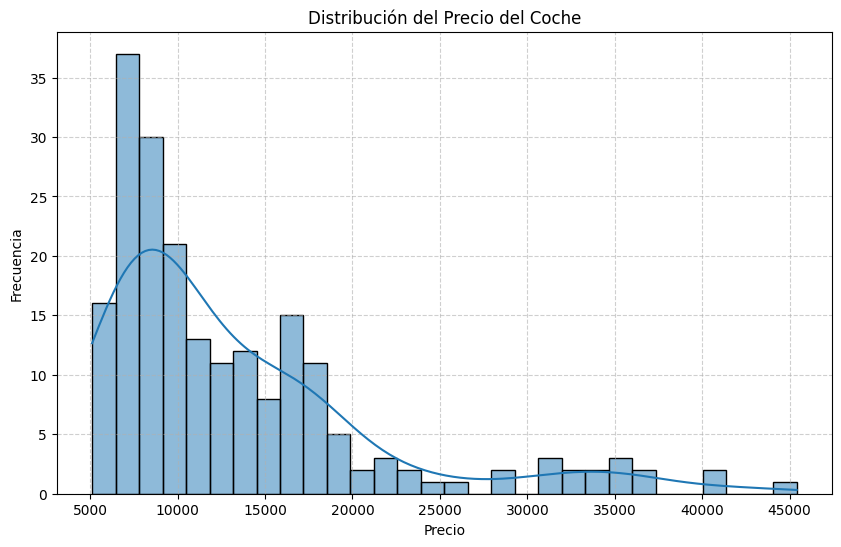

In [11]:
# Gráfico de distribución de la variable objetivo 'price'
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribución del Precio del Coche')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Gráfico de Correlación entre Variables Numéricas

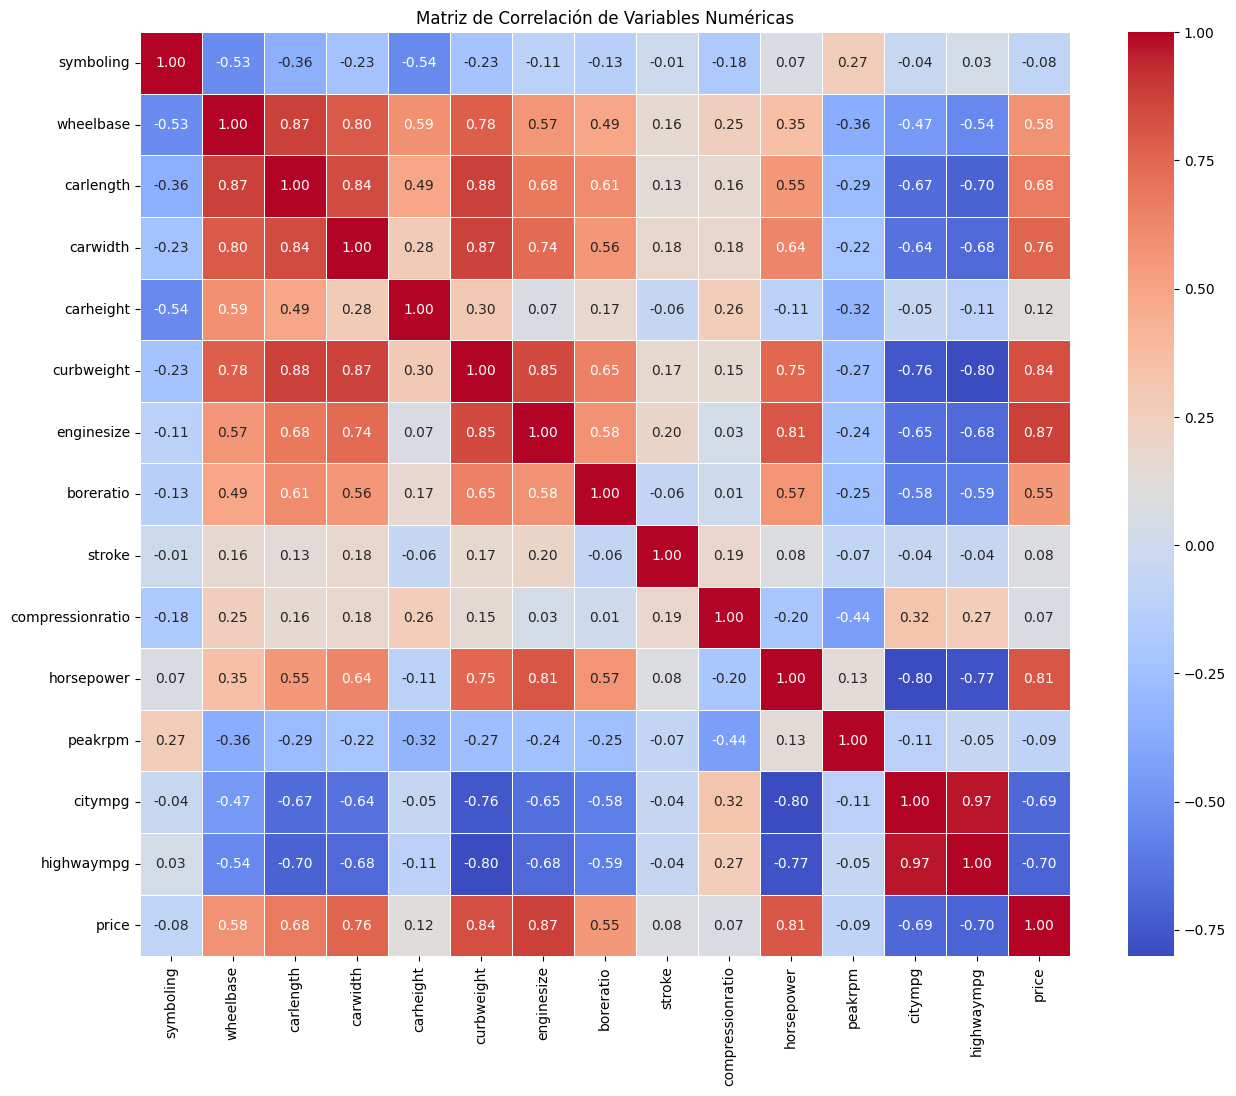

In [12]:
# Gráfico de matriz de correlación para las variables numéricas (incluyendo 'price')
plt.figure(figsize=(15, 12))
sns.heatmap(df[numeric_cols + ['price']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Parte 3 – Preparación de datos

#### 1. Codificación de variables categóricas

In [13]:
# Codificación One-Hot para variables categóricas
# Excluimos 'CarName' por su alta cardinalidad y posible irrelevancia directa o redundancia con otras features.
df_encoded = df.drop('CarName', axis=1)
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols[1:], drop_first=True)

print("Dimensiones del DataFrame después de la codificación One-Hot:", df_encoded.shape)
display(df_encoded.head())

Dimensiones del DataFrame después de la codificación One-Hot: (205, 45)


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


#### 2. Separación en X (variables predictoras) y y (variable objetivo)

In [14]:
# Definir X (features) y y (target)
X = df_encoded.drop(['price', 'car_ID'], axis=1) # Excluir 'price' y 'car_ID' de las características
y = df_encoded['price'] # Variable objetivo

print("Forma de X (predictoras):", X.shape)
print("Forma de y (objetivo):", y.shape)
display(X.head())

Forma de X (predictoras): (205, 43)
Forma de y (objetivo): (205,)


,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,True,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,True,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,True,False,False


#### 3. División del conjunto de datos (entrenamiento / prueba)

In [15]:
# División del dataset en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

Forma de X_train: (164, 43)
Forma de X_test: (41, 43)
Forma de y_train: (164,)
Forma de y_test: (41,)


### Parte 4 – Modelado

#### 1. Modelo de Regresión Lineal

In [16]:
# Inicializar y entrenar el modelo de Regresión Lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_linear = linear_model.predict(X_test)

print("Modelo de Regresión Lineal entrenado.")

Modelo de Regresión Lineal entrenado.


#### 2. Modelo de Random Forest Regressor

In [17]:
# Inicializar y entrenar el modelo de Random Forest Regressor
# Usamos un random_state para reproducibilidad
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = random_forest_model.predict(X_test)

print("Modelo de Random Forest Regressor entrenado.")

Modelo de Random Forest Regressor entrenado.


### Parte 5 – Evaluación del Modelo (Regresión)

#### Evaluación del Modelo de Regresión Lineal

In [18]:
# Calcular métricas de evaluación para el modelo de Regresión Lineal
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Métricas para el Modelo de Regresión Lineal:")
print(f"  MAE (Error Absoluto Medio): {mae_linear:.2f}")
print(f"  MSE (Error Cuadrático Medio): {mse_linear:.2f}")
print(f"  R² (Coeficiente de Determinación): {r2_linear:.2f}")

Métricas para el Modelo de Regresión Lineal:
  MAE (Error Absoluto Medio): 2089.38
  MSE (Error Cuadrático Medio): 8482008.48
  R² (Coeficiente de Determinación): 0.89


#### Evaluación del Modelo de Random Forest Regressor

In [19]:
# Calcular métricas de evaluación para el modelo de Random Forest Regressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Métricas para el Modelo de Random Forest Regressor:")
print(f"  MAE (Error Absoluto Medio): {mae_rf:.2f}")
print(f"  MSE (Error Cuadrático Medio): {mse_rf:.2f}")
print(f"  R² (Coeficiente de Determinación): {r2_rf:.2f}")

Métricas para el Modelo de Random Forest Regressor:
  MAE (Error Absoluto Medio): 1261.42
  MSE (Error Cuadrático Medio): 3314701.74
  R² (Coeficiente de Determinación): 0.96


### Parte 6 – Interpretación

Ahora, basándonos en las métricas obtenidas, podemos responder a las preguntas de interpretación:

1.  **¿Qué tan bueno es el modelo?**
    *   **Regresión Lineal:**
        *   Un valor de R² cercano a 1 indica que el modelo explica una gran proporción de la varianza en la variable objetivo.
        *   El MAE y MSE nos dan una idea del error promedio en las predicciones. Cuanto menores sean, mejor.
    *   **Random Forest Regressor:**
        *   Compara sus métricas (MAE, MSE, R²) con las de la Regresión Lineal. Generalmente, Random Forest suele tener un mejor rendimiento en datasets complejos debido a su capacidad para capturar relaciones no lineales.

2.  **¿Qué variable parece influir más en la predicción?**
    *   Para la Regresión Lineal, podemos examinar los **coeficientes** del modelo para identificar las variables con mayor peso. Las variables con coeficientes de mayor magnitud (absoluta) son las que más influyen.
    *   Para Random Forest, podemos analizar la **importancia de las características** (`feature_importances_`) para ver cuáles variables contribuyen más a las predicciones del modelo. Esto nos dará una indicación de las características más relevantes.

3.  **¿Qué mejorarías si tuvieras más tiempo?**
    *   **Ingeniería de Características:** Crear nuevas características a partir de las existentes (ej. relación longitud/ancho, potencia/peso). Podríamos también analizar más a fondo la columna 'CarName' para extraer información de la marca o modelo que pueda ser relevante.
    *   **Optimización de Hiperparámetros:** Usar técnicas como GridSearchCV o RandomizedSearchCV para ajustar los parámetros de los modelos (especialmente Random Forest) y mejorar su rendimiento.
    *   **Exploración de Modelos:** Probar otros modelos más avanzados como Gradient Boosting (XGBoost, LightGBM), o redes neuronales.
    *   **Manejo de Outliers:** Identificar y tratar los valores atípicos (outliers) que podrían estar afectando el rendimiento del modelo.
    *   **Análisis de Errores:** Examinar dónde el modelo comete los mayores errores para entender las limitaciones y posibles mejoras.

In [20]:
# Para la pregunta 2, vamos a mostrar la importancia de las características para ambos modelos (si aplica)

print("\n--- Análisis de Importancia de Variables ---\n")

# Regresión Lineal: Coeficientes
print("Variables más influyentes (Regresión Lineal - Coeficientes Absolutos):")
linear_coefs = pd.Series(linear_model.coef_, index=X.columns).abs().sort_values(ascending=False)
print(linear_coefs.head(10))

# Random Forest: Importancia de características
print("\nVariables más influyentes (Random Forest - Feature Importance):")
rf_feature_importances = pd.Series(random_forest_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(rf_feature_importances.head(10))


--- Análisis de Importancia de Variables ---

Variables más influyentes (Regresión Lineal - Coeficientes Absolutos):
cylindernumber_twelve    12084.383796
enginelocation_rear      10821.593993
cylindernumber_four       8475.125200
cylindernumber_five       7513.575766
cylindernumber_six        7427.344430
enginetype_dohcv          5780.366342
enginetype_ohcv           4254.477259
stroke                    3874.928459
carbody_hardtop           3794.612567
carbody_wagon             3228.522812
dtype: float64

Variables más influyentes (Random Forest - Feature Importance):
enginesize    0.544441
curbweight    0.299421
highwaympg    0.045694
horsepower    0.035511
carwidth      0.013533
carlength     0.009019
wheelbase     0.007541
peakrpm       0.006795
citympg       0.006493
stroke        0.004913
dtype: float64


1. Variable Objetivo (Target): La variable objetivo es 'price'.

2. Tipo de Problema: Es un problema de regresión.

Por qué: Porque la variable 'price' es una variable cuantitativa continua, es decir, representa valores numéricos que pueden tomar cualquier valor dentro de un rango determinado (el precio de los coches). El objetivo es predecir un valor numérico continuo, no una categoría.

3. Contexto del Problema: El contexto de este problema es predecir el precio de un coche basándose en un conjunto de características del vehículo. Estas características pueden incluir atributos como la marca, el tipo de combustible, el tipo de aspiración del motor, el tipo de carrocería, el número de puertas, y diversas dimensiones del motor y el vehículo. En esencia, se trata de un análisis para entender y pronosticar los precios de los automóviles en función de sus especificaciones.